## Cable Theory

In [ ]:
using PlotlyJS

# --- Constants ---
# Membrane properties
C_m = 1.0   # Membrane capacitance (µF/cm^2)
g_L = 0.001 # Leak conductance (S/cm^2) 
E_L = -65.0  # Leak reversal potential (mV)

# Cable properties
d = 10.0     # Cable diameter (µm)
L = 1000.0  # Cable length (µm)
r_a = 100.0  # Axial resistivity (Ω*cm)

# Derived parameters
A = π * d^2 / 4  # Cross-sectional area (µm^2)
λ = sqrt(1 / (4 * r_a * g_L * A / 1e8)) # Space constant (µm)


1784.1241161527712

In [53]:

# --- Simulation parameters ---
dx = 20.0   # Spatial step (µm)
dt = 0.01  # Time step (ms)
t_end = 100.0 # Total simulation time (ms)
t = 0:dt:t_end

# --- Spatial discretization ---
x = 0:dx:L
Nx = length(x)

# --- Input current ---
I_inj = zeros(Nx)
I_inj[Int(round(Nx/2))] = 20.0 # Inject current at the middle
t_inj_start = 0
t_inj_end = 10 # ms

# --- Initialization ---
V = -65.0 * ones(Nx, length(t)) # Initialize membrane potential

# --- Simulation loop ---
for j in 2:length(t)
    # Calculate spatial derivatives (second-order central difference)
    d2Vdx2 = zeros(Nx)
    d2Vdx2[1] = (V[2, j-1] - 2*V[1, j-1] + V[1, j-1]) / dx^2  # Forward difference at x = 0
    d2Vdx2[2:Nx-1] = (V[1:Nx-2, j-1] - 2*V[2:Nx-1, j-1] + V[3:Nx, j-1]) / dx^2 # Central difference
    d2Vdx2[Nx] = (V[Nx-1, j-1] - 2*V[Nx, j-1] + V[Nx, j-1]) / dx^2  # Backward difference at x = L

    # Membrane current calculations
    I_L = g_L .* (V[:, j-1] .- E_L)

    # # Update membrane potential using the cable equation (with g_L)
    if t_inj_start <= t[j] <= t_inj_end
        V[:, j] = V[:, j-1] + dt/C_m * (d2Vdx2 * (d * 1e4) ./ (4 * r_a) .- I_L .+ I_inj)
    else
        V[:, j] = V[:, j-1] + dt/C_m * (d2Vdx2 * (d * 1e4) ./ (4 * r_a) .- I_L)
    end 
end


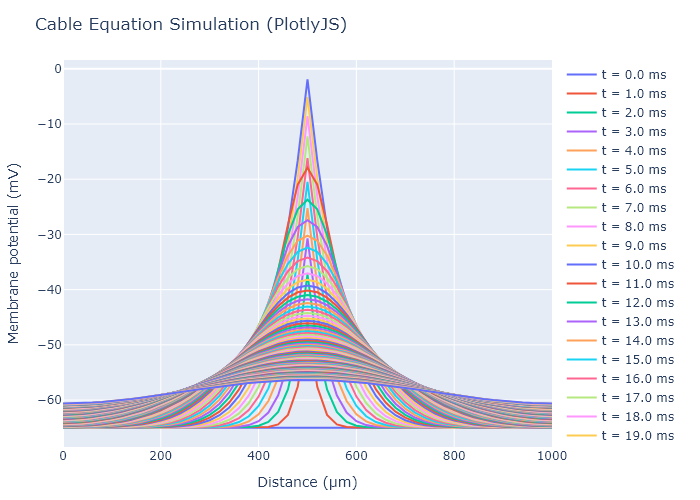

In [54]:

# --- Plotting with PlotlyJS ---
traces = PlotlyJS.AbstractTrace[]
for j in 1:100:length(t)
    trace = PlotlyJS.scatter(;x=x, y=V[:, j], mode="lines", name="t = $(round(t[j], digits=2)) ms") 
    push!(traces, trace)
end

layout = Layout(
    xaxis_title="Distance (µm)",
    yaxis_title="Membrane potential (mV)",
    title="Cable Equation Simulation (PlotlyJS)"
)

plt = PlotlyJS.plot(traces, layout)
display(plt)

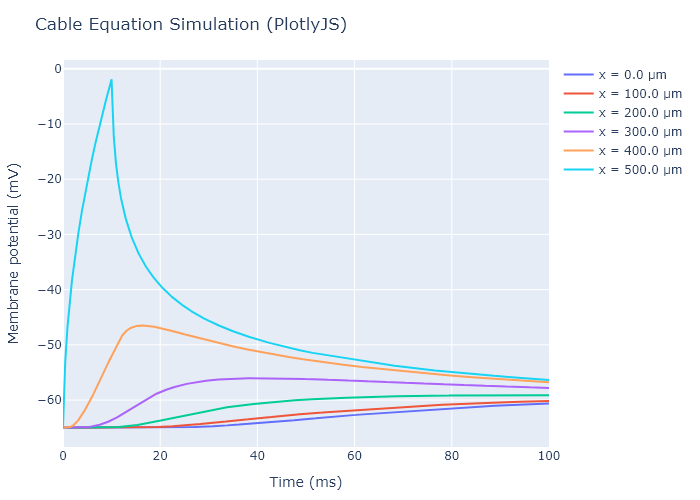

In [55]:
# --- Plotting with PlotlyJS (Time as x-axis) ---
traces = PlotlyJS.AbstractTrace[]
for i in 1:5:Int(round(Nx/2)) # Plot every 5th compartment
    trace = PlotlyJS.scatter(;x=t, y=V[i, :], mode="lines", name="x = $(x[i]) µm")
    push!(traces, trace)
end

layout = Layout(
    xaxis_title="Time (ms)",
    yaxis_title="Membrane potential (mV)",
    title="Cable Equation Simulation (PlotlyJS)"
)

plt = PlotlyJS.plot(traces, layout)
display(plt)